In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Bidirectional, GRU, Dense
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- Step 1: Generate the input and target dataset (from your code) ---
np.random.seed(42)
tf.random.set_seed(42)

num_sequences = 10000
sequence_length = 30
input_dim = 1

X = np.zeros((num_sequences, sequence_length, input_dim))
Y = np.zeros((num_sequences, sequence_length, input_dim))

for i in range(num_sequences):
    mean = np.random.uniform(-10, 10)
    std = np.random.uniform(0.1, 0.5)
    X[i, :, 0] = np.random.normal(mean, std, sequence_length)

Y = np.copy(X)
decoder_input = np.zeros_like(Y)
decoder_input[:, 1:, :] = Y[:, :-1, :]

In [3]:
# --- Step 2: Build the Seq2Seq RNN model with Bidirectional GRU ---
# --- Hyperparameters ---
latent_dim = 64  # Adjust as needed

# --- Encoder ---
encoder_inputs = Input(shape=(sequence_length, input_dim), name="encoder_inputs")
encoder_gru = Bidirectional(GRU(latent_dim, return_state=True), merge_mode='concat') 
encoder_outputs, forward_h, backward_h = encoder_gru(encoder_inputs)
# Concatenate the forward and backward hidden states
encoder_state = tf.keras.layers.concatenate([forward_h, backward_h], axis=-1)

# --- Decoder ---
decoder_inputs = Input(shape=(sequence_length, input_dim), name="decoder_inputs")
decoder_gru = GRU(latent_dim * 2, return_sequences=True, return_state=True)  # Double the units
decoder_outputs, _ = decoder_gru(decoder_inputs, initial_state=encoder_state) 
decoder_dense = Dense(input_dim, activation="linear", name="decoder_dense") 
decoder_outputs = decoder_dense(decoder_outputs)

# --- Combined Seq2Seq model ---
seq2seq_rnn = Model([encoder_inputs, decoder_inputs], decoder_outputs)
seq2seq_rnn.compile(optimizer="adam", loss="mse")

In [4]:
# --- Step 3: Train the model ---
seq2seq_rnn.fit([X, decoder_input], Y, batch_size=5000, epochs=50, validation_split=0.2)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 559ms/step - loss: 32.1460 - val_loss: 26.9743
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - loss: 25.4975 - val_loss: 20.8937
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 455ms/step - loss: 19.6627 - val_loss: 15.6547
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 471ms/step - loss: 14.6553 - val_loss: 11.2882
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step - loss: 10.5049 - val_loss: 7.8154
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step - loss: 7.2323 - val_loss: 5.2451
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 478ms/step - loss: 4.8458 - val_loss: 3.5617
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step - loss: 3.3261 - val_loss: 2.6866
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 490ms/step - loss: 2.5825 - val_loss: 2.4234
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 484ms/step - loss: 2.4010 - val_loss: 2.4539
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 484ms/step - loss: 2.4566 - val_loss: 2.4590
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 479ms/step - loss: 2.4470

In [5]:
# --- Step 4: Prediction and Evaluation (similar to your code) ---
# Step 4: Predict using the decoder with teacher forcing
decoded_predictions = seq2seq_rnn.predict([X, decoder_input], verbose=0)

# teacher forcing are also used in prediction, this should be fixed!

In [6]:
# Step 5: Print 20 random sequences for evaluation
print("\n--- Evaluation of Random Sequences ---\n")
for i in np.random.choice(range(num_sequences), size=20, replace=False):
    print(f"Sequence {i + 1}:")
    print(f"Input X:\n{X[i, :, 0]}")
    print(f"Actual Y:\n{Y[i, :, 0]}")
    print(f"Predicted Y:\n{decoded_predictions[i, :, 0]}")
    print("-" * 50)

# Set random sequences for visualization
random_indices = np.random.choice(range(num_sequences), size=20, replace=False)


--- Evaluation of Random Sequences ---

Sequence 8401:
Input X:
[1.71250715 1.56461532 1.91026295 1.56997851 1.69338553 1.56358426
 1.58908738 1.75338084 1.84164944 1.51923693 1.94446275 1.53455041
 1.57949864 1.77608355 1.75776221 1.93069548 1.74426414 1.72278574
 1.57250237 1.66515408 1.48767035 1.76268138 1.61609741 1.5769891
 1.74755834 1.52441183 1.59445121 1.8094456  1.6545126  1.60238689]
Actual Y:
[1.71250715 1.56461532 1.91026295 1.56997851 1.69338553 1.56358426
 1.58908738 1.75338084 1.84164944 1.51923693 1.94446275 1.53455041
 1.57949864 1.77608355 1.75776221 1.93069548 1.74426414 1.72278574
 1.57250237 1.66515408 1.48767035 1.76268138 1.61609741 1.5769891
 1.74755834 1.52441183 1.59445121 1.8094456  1.6545126  1.60238689]
Predicted Y:
[1.8695203 1.5438832 1.4573852 1.5538825 1.6509675 1.7081743 1.715814
 1.6921421 1.708187  1.7756665 1.770889  1.8050708 1.7944213 1.7292069
 1.7199053 1.7544464 1.8341663 1.8806636 1.8697788 1.8006135 1.7361033
 1.6617552 1.6552213 1.6758196

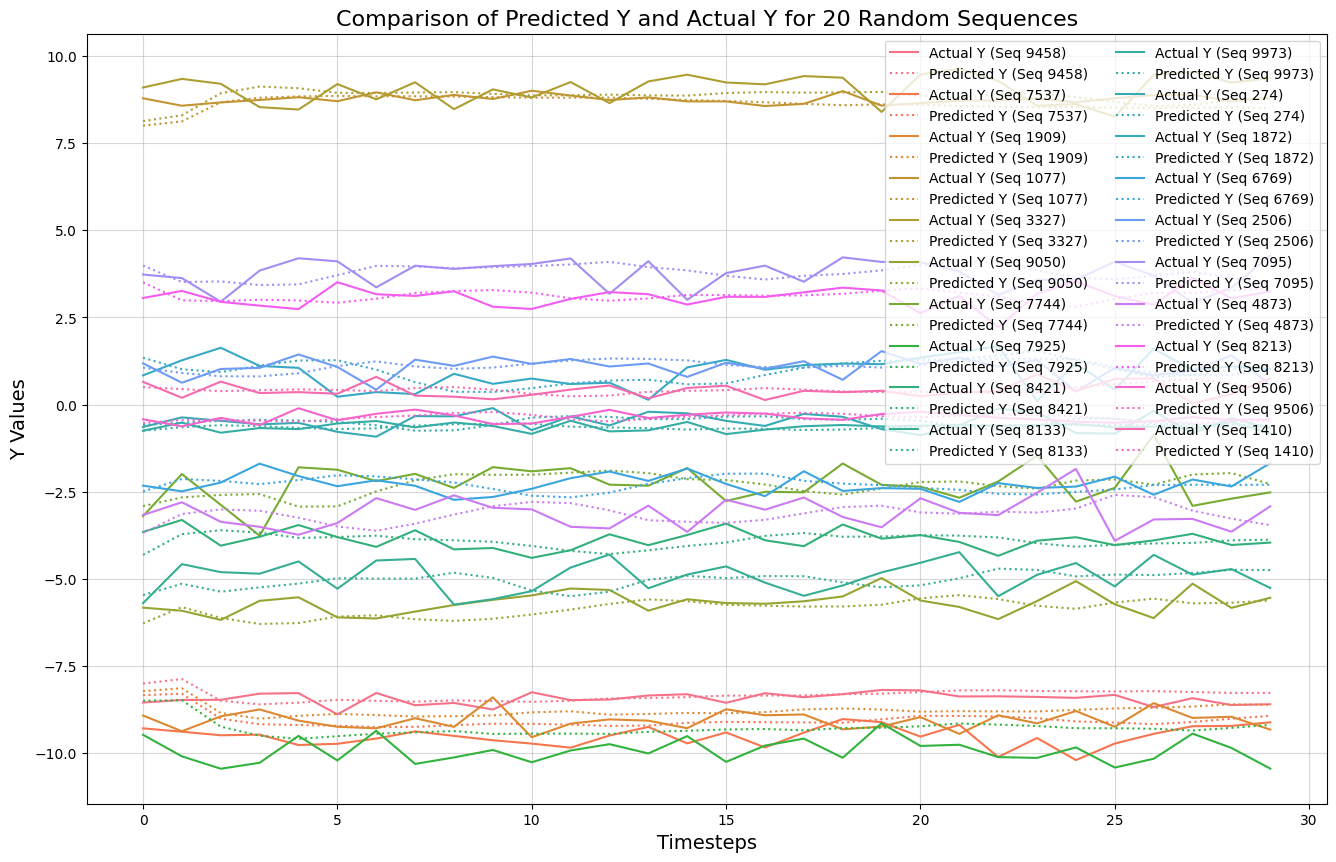

In [7]:
# 1. Line chart comparing RNN predicted Y and actual Y for 20 sequences
plt.figure(figsize=(16, 10))
for idx, seq_idx in enumerate(random_indices):
    actual = Y[seq_idx, :, 0]
    predicted = decoded_predictions[seq_idx, :, 0]
    
    # Plot actual Y (solid line)
    plt.plot(range(sequence_length), actual, label=f"Actual Y (Seq {seq_idx+1})", color=sns.color_palette("husl", 20)[idx])
    
    # Plot predicted Y (dotted line)
    plt.plot(range(sequence_length), predicted, linestyle="dotted", label=f"Predicted Y (Seq {seq_idx+1})", color=sns.color_palette("husl", 20)[idx])

plt.title("Comparison of Predicted Y and Actual Y for 20 Random Sequences", fontsize=16)
plt.xlabel("Timesteps", fontsize=14)
plt.ylabel("Y Values", fontsize=14)
plt.legend(fontsize=10, ncol=2, loc="upper right")
plt.grid(alpha=0.5)
plt.show()

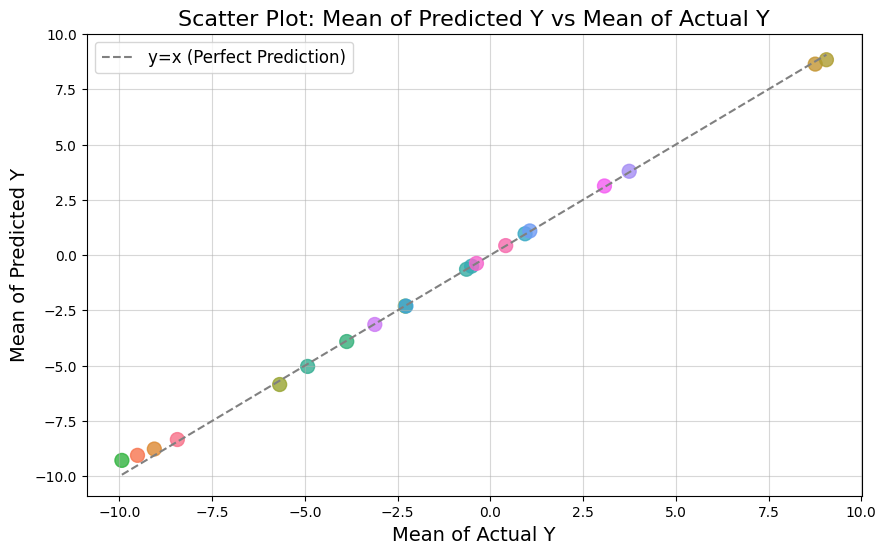

In [8]:
# 2. Scatter plot: mean of predicted Y vs mean of actual Y for the 20 sequences
actual_means = [Y[idx, :, 0].mean() for idx in random_indices]
predicted_means = [decoded_predictions[idx, :, 0].mean() for idx in random_indices]

plt.figure(figsize=(10, 6))
plt.scatter(actual_means, predicted_means, c=sns.color_palette("husl", 20), s=100, alpha=0.8)
plt.plot([min(actual_means), max(actual_means)], [min(actual_means), max(actual_means)], linestyle="--", color="gray", label="y=x (Perfect Prediction)")
plt.title("Scatter Plot: Mean of Predicted Y vs Mean of Actual Y", fontsize=16)
plt.xlabel("Mean of Actual Y", fontsize=14)
plt.ylabel("Mean of Predicted Y", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)
plt.show()